## BÀI TẬP NHÓM
### PHÂN LOẠI GIỚI TÍNH QUA GIỌNG NÓI DÙNG DECISION TREE, KNN, SVM, RANDOM FOREST
NHÓM: 

Nguyễn Phú Thành

Cao Thị Ngọc Phụng

Trần Văn Tiến

Đinh Thị Thúy Quỳnh

### Tìm hiểu tổng quan về dữ liệu
Phần này sẽ dùng tập dữ liệu `voice.csv` để minh họa. (3168 DÒNG)

Cơ sở dữ liệu này được tạo ra để nhận diện giọng nói là nam hay nữ, dựa trên các đặc tính âm thanh của giọng nói và lời nói. Bộ dữ liệu bao gồm 3.168 mẫu giọng nói được ghi âm, được thu thập từ các loại loại nam và nữ. Các mẫu giọng nói đã được tiền xử lý bằng phân tích âm thanh trong R bằng cách sử dụng các gói seewave và tuneR, với dải tần số phân tích từ 0Hz đến 280Hz (phạm vi tần số giọng nói của con người).

###### The Dataset
Các đặc tính âm thanh sau của mỗi giọng được đo và bao gồm trong tập tin CSV:
meanfreq: tần số trung bình (đơn vị kHz)
sd: độ lệch chuẩn của tần số
median: tần số trung vị (đơn vị kHz)
Q25: phân vị thứ nhất (đơn vị kHz)
Q75: phân vị thứ ba (đơn vị kHz)
IQR: phạm vi giữa các phân vị (đơn vị kHz)
skew: độ lệch (xem ghi chú trong mô tả specprop)
kurt: độ nhọn (xem ghi chú trong mô tả specprop)
sp.ent: entropy phổ
sfm: đồng phẳng phổ
mode: tần số mode
centroid: trọng tâm tần số (xem specprop)
peakf: tần số đỉnh (tần số có năng lượng cao nhất)
meanfun: trung bình của tần số cơ bản đo được trên tín hiệu âm thanh
minfun: tần số cơ bản tối thiểu đo được trên tín hiệu âm thanh
maxfun: tần số cơ bản tối đa đo được trên tín hiệu âm thanh
meandom: trung bình của tần số nổi bật đo được trên tín hiệu âm thanh
mindom: tần số nổi bật tối thiểu đo được trên tín hiệu âm thanh
maxdom: tần số nổi bật tối đa đo được trên tín hiệu âm thanh
dfrange: phạm vi của tần số nổi bật đo được trên tín hiệu âm thanh
modindx: chỉ số biến đổi. Tính toán như sự khác biệt tuyệt đối tích lũy giữa các đo lường liên tiếp của tần số cơ bản chia cho phạm vi tần số
label: nam hoặc nữ
####  Import Library và load data

In [165]:
import numpy as np  # Đại số tuyến tính
import pandas as pd  # Xử lý dữ liệu, đọc và ghi file CSV (ví dụ: pd.read_csv)
import matplotlib.pyplot as plt  # Trực quan hóa dữ liệu
import seaborn as sns  # Thư viện trực quan hóa dữ liệu nâng cao

In [166]:
voice=pd.read_csv('D:/DAMI (Data Mining)/MIDTERM/voice.csv')

In [167]:
# Xem 5 hàng đầu tiên của data 
voice.head()

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


In [168]:
#Đưa ra thông tin data
voice.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3168 entries, 0 to 3167
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   meanfreq  3168 non-null   float64
 1   sd        3168 non-null   float64
 2   median    3168 non-null   float64
 3   Q25       3168 non-null   float64
 4   Q75       3168 non-null   float64
 5   IQR       3168 non-null   float64
 6   skew      3168 non-null   float64
 7   kurt      3168 non-null   float64
 8   sp.ent    3168 non-null   float64
 9   sfm       3168 non-null   float64
 10  mode      3168 non-null   float64
 11  centroid  3168 non-null   float64
 12  meanfun   3168 non-null   float64
 13  minfun    3168 non-null   float64
 14  maxfun    3168 non-null   float64
 15  meandom   3168 non-null   float64
 16  mindom    3168 non-null   float64
 17  maxdom    3168 non-null   float64
 18  dfrange   3168 non-null   float64
 19  modindx   3168 non-null   float64
 20  label     3168 non-null   obje

In [169]:
#mô tả data
voice.describe()

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,mode,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx
count,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000
mean,0.180907,0.057126,0.185621,0.140456,0.224765,0.084309,3.140168,36.568461,0.895127,0.408216,0.165282,0.180907,0.142807,0.036802,0.258842,0.829211,0.052647,5.047277,4.994630,0.173752
std,0.029918,0.016652,0.036360,0.048680,0.023639,0.042783,4.240529,134.928661,0.044980,0.177521,0.077203,0.029918,0.032304,0.019220,0.030077,0.525205,0.063299,3.521157,3.520039,0.119454
min,0.039363,0.018363,0.010975,0.000229,0.042946,0.014558,0.141735,2.068455,0.738651,0.036876,0.000000,0.039363,0.055565,0.009775,0.103093,0.007812,0.004883,0.007812,0.000000,0.000000
25%,0.163662,0.041954,0.169593,0.111087,0.208747,0.042560,1.649569,5.669547,0.861811,0.258041,0.118016,0.163662,0.116998,0.018223,0.253968,0.419828,0.007812,2.070312,2.044922,0.099766
50%,0.184838,0.059155,0.190032,0.140286,0.225684,0.094280,2.197101,8.318463,0.901767,0.396335,0.186599,0.184838,0.140519,0.046110,0.271186,0.765795,0.023438,4.992188,4.945312,0.139357
75%,0.199146,0.067020,0.210618,0.175939,0.243660,0.114175,2.931694,13.648905,0.928713,0.533676,0.221104,0.199146,0.169581,0.047904,0.277457,1.177166,0.070312,7.007812,6.992188,0.209183
max,0.251124,0.115273,0.261224,0.247347,0.273469,0.252225,34.725453,1309.612887,0.981997,0.842936,0.280000,0.251124,0.237636,0.204082,0.279114,2.957682,0.458984,21.867188,21.843750,0.932374


### Tiền xử lý: label encoder and normalization


In [170]:
from sklearn import preprocessing  # Tiền xử lý dữ liệu
le = preprocessing.LabelEncoder()  # Mã hóa nhãn
voice["label"] = le.fit_transform(voice["label"])  # Áp dụng mã hóa nhãn cho cột "label" trong dataframe
le.classes_  # Hiển thị các lớp đã được mã hóa

array(['female', 'male'], dtype=object)

In [171]:
voice[:] = preprocessing.MinMaxScaler().fit_transform(voice)  # Chuẩn hóa dữ liệu sử dụng Min-Max Scaler và gán lại vào dataframe voice
voice.head()  # Hiển thị 5 dòng đầu tiên của dataframe voice sau khi đã được chuẩn hóa

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.096419,0.473409,0.084125,0.060063,0.204956,0.254828,0.367853,0.208279,0.635798,0.564526,...,0.096419,0.157706,0.030501,0.981526,0.000000,0.006452,0.000000,0.000000,0.000000,1
1,0.125828,0.505075,0.116900,0.077635,0.215683,0.246961,0.644279,0.483766,0.630964,0.591578,...,0.125828,0.287642,0.031140,0.834600,0.000407,0.006452,0.002144,0.002146,0.056449,1
2,0.179222,0.675536,0.102873,0.034284,0.385912,0.457148,0.885255,0.782275,0.442738,0.548382,...,0.179222,0.236945,0.030264,0.954963,0.000060,0.006452,0.000357,0.000358,0.049885,1
3,0.528261,0.554611,0.587559,0.389906,0.715802,0.407358,0.031549,0.001613,0.923261,0.856457,...,0.528261,0.183442,0.041287,0.834600,0.065659,0.006452,0.025375,0.025393,0.265043,1
4,0.452195,0.627209,0.454272,0.317627,0.707515,0.474474,0.027742,0.001732,0.958736,0.926348,...,0.452195,0.279190,0.036829,0.929285,0.238994,0.006452,0.250536,0.250715,0.223380,1


### Visualization: Hình dung sau khi xử lý

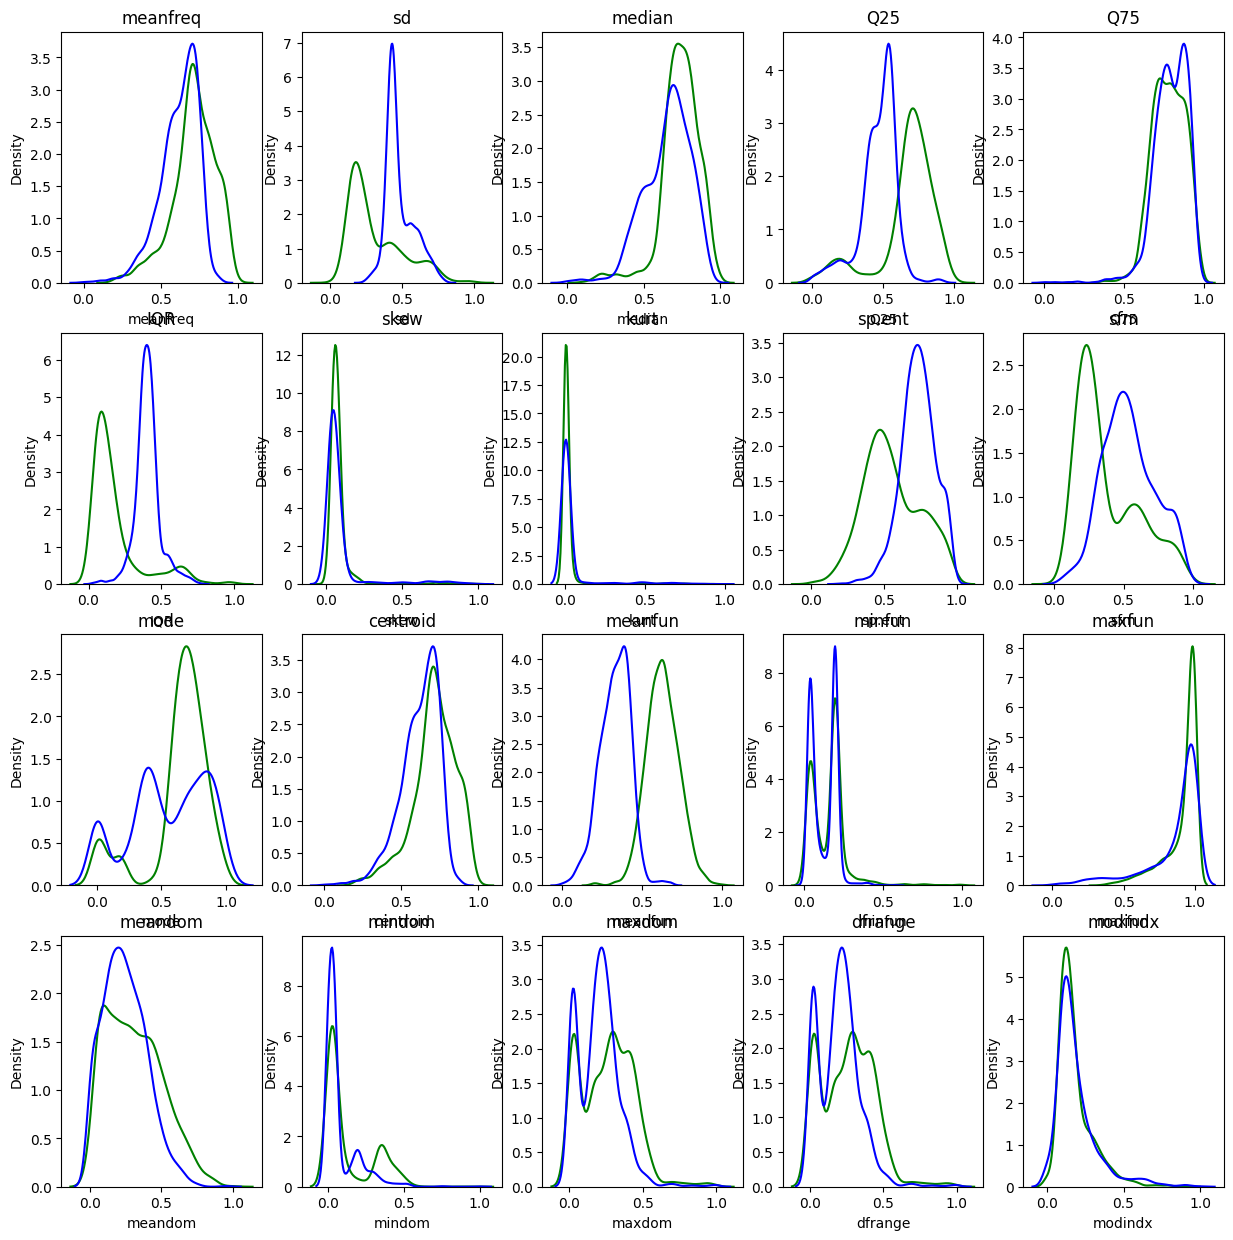

In [172]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.subplots(4,5,figsize=(15,15))
for i in range(1,21):
    plt.subplot(4,5,i)
    plt.title(voice.columns[i-1])
    sns.kdeplot(voice.loc[voice['label'] == 0, voice.columns[i-1]], color= 'green', label='F')
    sns.kdeplot(voice.loc[voice['label'] == 1, voice.columns[i-1]], color= 'blue', label='M')

###### Tính năng quan trọng nhất là Q25, IQR và Meanfun. 


###### Chúng ta sẽ xây dựng mô hình bằng cách sử dụng 20 đặc điểm và 3 đặc điểm riêng biệt.

### Using K-Nearest Neighbors,  Decision Tree, Random Forest, Support Vector Machine để xây dựng MODEL

In [173]:
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn import neighbors
from sklearn import tree
from sklearn import ensemble
from sklearn import svm

In [174]:
# Split the data
train, test = train_test_split(voice, test_size=0.3)

In [175]:
#Xem 5 dòng đầu tập dữ liệu train
train.head()

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
39,0.617899,0.553707,0.539578,0.520327,0.880348,0.431352,0.075302,0.007431,0.711744,0.592666,...,0.617899,0.395251,0.032868,0.834600,0.108700,0.006452,0.041458,0.041488,0.183995,1
2718,0.765289,0.169308,0.753007,0.741552,0.783429,0.107324,0.053218,0.003882,0.533163,0.231867,...,0.765289,0.604892,0.196231,0.954963,0.613387,0.040860,0.390994,0.390558,0.154428,0
2189,0.616263,0.361006,0.652630,0.607429,0.700217,0.166069,0.066914,0.006133,0.696110,0.580357,...,0.616263,0.464050,0.202281,0.999749,0.354704,0.195699,0.269836,0.266094,0.138932,0
1016,0.707826,0.396936,0.737282,0.572899,0.838924,0.336509,0.020941,0.001112,0.787576,0.425472,...,0.707826,0.375362,0.194279,0.963717,0.348843,0.040860,0.275197,0.274678,0.097058,1
21,0.668926,0.577918,0.632665,0.519769,0.916301,0.466803,0.070715,0.007811,0.725853,0.543931,...,0.668926,0.236600,0.032784,0.981526,0.068488,0.006452,0.168692,0.168813,0.064287,1


In [176]:
x_train = train.iloc[:, :-1]
y_train = train["label"]
x_test = test.iloc[:, :-1]
y_test = test["label"]

In [177]:
x_train3 = train[["meanfun","IQR","Q25"]]
y_train3 = train["label"]
x_test3 = test[["meanfun","IQR","Q25"]]
y_test3 = test["label"]

In [178]:
def classify(model,x_train,y_train,x_test,y_test):
    from sklearn.metrics import classification_report
    target_names = ['female', 'male']
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    print(classification_report(y_test, y_pred, target_names=target_names, digits=4))

## K-Nearest Neighbors
Using neighbors.KNeighborsClassifier() to build the model.


In [179]:
import numpy as np

x_train = np.array(x_train)
y_train = np.array(y_train)
x_test = np.array(x_test)
y_test = np.array(y_test)

In [180]:
def knn_error(k,x_train,y_train,x_test,y_test):
    error_rate = []  # Danh sách lưu tỉ lệ lỗi
    K = range(1, k)  # Tạo danh sách các giá trị k từ 1 đến k-1
    for i in K:
        knn = neighbors.KNeighborsClassifier(n_neighbors=i)  # Khởi tạo mô hình KNN với số lượng láng giềng là i
        knn.fit(x_train, y_train)  # Huấn luyện mô hình trên dữ liệu huấn luyện
        y_pred = knn.predict(x_test)  # Dự đoán nhãn của dữ liệu kiểm tra
        error_rate.append(np.mean(y_pred != y_test))  # Tính tỉ lệ lỗi và thêm vào danh sách
    kloc = error_rate.index(min(error_rate))  # Tìm vị trí của giá trị lỗi thấp nhất trong danh sách
    print("Lowest error is %s occurs at k=%s." % (error_rate[kloc], K[kloc]))
    
    # Vẽ biểu đồ tỉ lệ lỗi so với giá trị k
    plt.plot(K, error_rate, color='blue', linestyle='dashed', marker='o',
             markerfacecolor='red', markersize=10)
    plt.title('Error Rate vs. K Value')
    plt.xlabel('K')
    plt.ylabel('Error Rate')
    plt.show()
    return K[kloc] # Trả về giá trị k tương ứng với tỉ lệ lỗi thấp nhất

Lowest error is 0.016824395373291272 occurs at k=3.


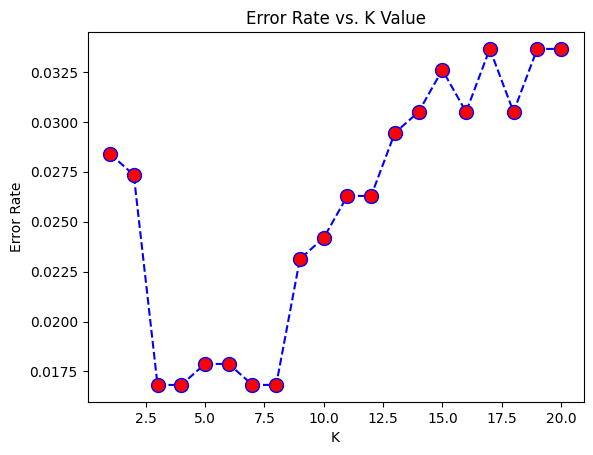

In [181]:
k=knn_error(21,x_train,y_train,x_test,y_test)

In [182]:
model = neighbors.KNeighborsClassifier(n_neighbors = k)
classify(model,x_train,y_train,x_test,y_test)

              precision    recall  f1-score   support

      female     0.9770    0.9894    0.9832       472
        male     0.9894    0.9770    0.9832       479

    accuracy                         0.9832       951
   macro avg     0.9832    0.9832    0.9832       951
weighted avg     0.9833    0.9832    0.9832       951



Lowest error is 0.025236593059936908 occurs at k=5.


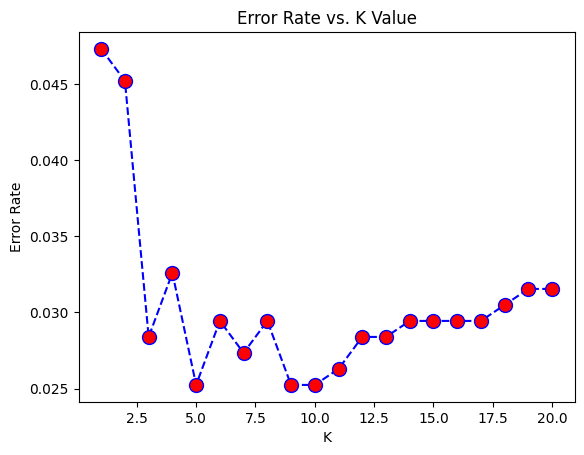

In [183]:
k=knn_error(21,x_train3,y_train3,x_test3,y_test3)

In [184]:
model = neighbors.KNeighborsClassifier(n_neighbors = k)
classify(model,x_train,y_train,x_test,y_test)

              precision    recall  f1-score   support

      female     0.9830    0.9809    0.9820       472
        male     0.9812    0.9833    0.9823       479

    accuracy                         0.9821       951
   macro avg     0.9821    0.9821    0.9821       951
weighted avg     0.9821    0.9821    0.9821       951



## Decision Tree
Using tree.DecisionTreeClassifier() để xây dựng MODEL

In [185]:
def dt_error(n,x_train,y_train,x_test,y_test):
    nodes = range(2, n)  # Tạo danh sách các số node lá từ 2 đến n-1
    error_rate = []  # Danh sách lưu tỉ lệ lỗi
    for k in nodes:
        model = tree.DecisionTreeClassifier(max_leaf_nodes=k)  # Khởi tạo mô hình cây quyết định với số lượng node lá là k
        model.fit(x_train, y_train)  # Huấn luyện mô hình trên dữ liệu huấn luyện
        y_pred = model.predict(x_test)  # Dự đoán nhãn của dữ liệu kiểm tra
        error_rate.append(np.mean(y_pred != y_test))  # Tính tỉ lệ lỗi và thêm vào danh sách
    kloc = error_rate.index(min(error_rate))  # Tìm vị trí của giá trị lỗi thấp nhất trong danh sách
    print("Lowest error is %s occurs at n=%s." % (error_rate[kloc], nodes[kloc]))
       
    # Vẽ biểu đồ tỉ lệ lỗi so với kích thước cây
    plt.plot(nodes, error_rate, color='blue', linestyle='dashed', marker='o',
             markerfacecolor='red', markersize=10)
    plt.xlabel('Tree Size')
    plt.ylabel('Cross-Validated MSE')
    plt.show()
    return nodes[kloc]

### Áp dụng ID3

Lowest error is 0.03470031545741325 occurs at n=9.


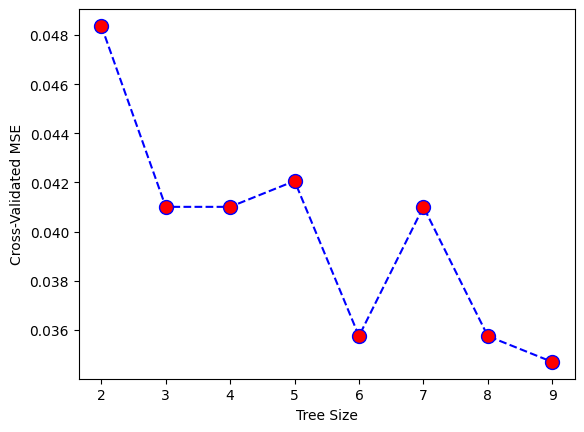

Accuracy of pruned ID3 tree: 0.9589905362776026


In [186]:
# Áp dụng ID3
n_id3 = dt_error(10, x_train, y_train, x_test, y_test)

# Huấn luyện cây quyết định ID3 với số lượng node lá tối ưu
pruned_tree_id3 = tree.DecisionTreeClassifier(criterion='entropy', max_leaf_nodes=n_id3)
pruned_tree_id3.fit(x_train, y_train)
accuracy_id3 = pruned_tree_id3.score(x_test, y_test)
print("Accuracy of pruned ID3 tree:", accuracy_id3)

### Áp dụng C4.5

Lowest error is 0.03470031545741325 occurs at n=9.


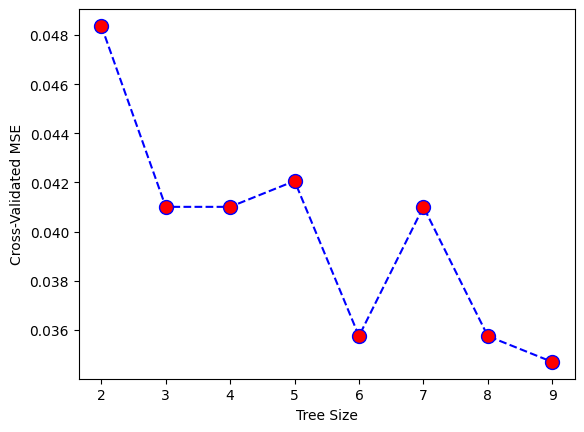

Accuracy of pruned C4.5 tree: 0.9652996845425867


In [187]:
# Áp dụng C4.5 
n_c45 = dt_error(10, x_train, y_train, x_test, y_test)

# Huấn luyện cây quyết định C4.5 với số lượng node lá tối ưu
pruned_tree_c45 = tree.DecisionTreeClassifier(criterion='gini', max_leaf_nodes=n_c45)
pruned_tree_c45.fit(x_train, y_train)
accuracy_c45 = pruned_tree_c45.score(x_test, y_test)
print("Accuracy of pruned C4.5 tree:", accuracy_c45)

### Áp dụng CART

Lowest error is 0.03470031545741325 occurs at n=9.


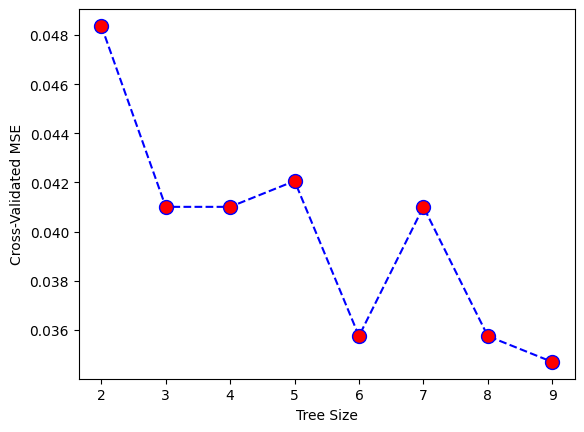

Accuracy of pruned CART tree: 0.9652996845425867


In [188]:
# Áp dụng CART
n_cart = dt_error(10, x_train, y_train, x_test, y_test)

# Huấn luyện cây quyết định CART với số lượng node lá tối ưu
pruned_tree_cart = tree.DecisionTreeClassifier(criterion='gini', max_leaf_nodes=n_cart)
pruned_tree_cart.fit(x_train, y_train)
accuracy_cart = pruned_tree_cart.score(x_test, y_test)
print("Accuracy of pruned CART tree:", accuracy_cart)


## Random Forest
Using ensemble.RandomForestClassifier() để xây dựng model

In [189]:
def rf_error(n,x_train,y_train,x_test,y_test):
    error_rate = []  # Danh sách lưu tỉ lệ lỗi
    e = range(1, n, 20)  # Tạo danh sách các giá trị n_estimators từ 1 đến n với bước nhảy là 20
    for i in e:
        model = ensemble.RandomForestClassifier(n_estimators=i)  # Khởi tạo mô hình Random Forest với số lượng cây là i
        model.fit(x_train, y_train)  # Huấn luyện mô hình trên dữ liệu huấn luyện
        y_pred = model.predict(x_test)  # Dự đoán nhãn của dữ liệu kiểm tra
        error_rate.append(np.mean(y_pred != y_test))  # Tính tỉ lệ lỗi và thêm vào danh sách
    nloc = error_rate.index(min(error_rate))  # Tìm vị trí của giá trị lỗi thấp nhất trong danh sác
    print("Lowest error is %s occurs at n=%s." % (error_rate[nloc], e[nloc]))
    
    # Vẽ biểu đồ tỉ lệ lỗi so với giá trị n_estimators
    plt.plot(e, error_rate, color='blue', linestyle='dashed', marker='o',
             markerfacecolor='red', markersize=10)
    plt.title('Error Rate vs. n Value')
    plt.xlabel('n')
    plt.ylabel('Error Rate')
    plt.show()
    return e[nloc]

Lowest error is 0.023133543638275498 occurs at n=81.


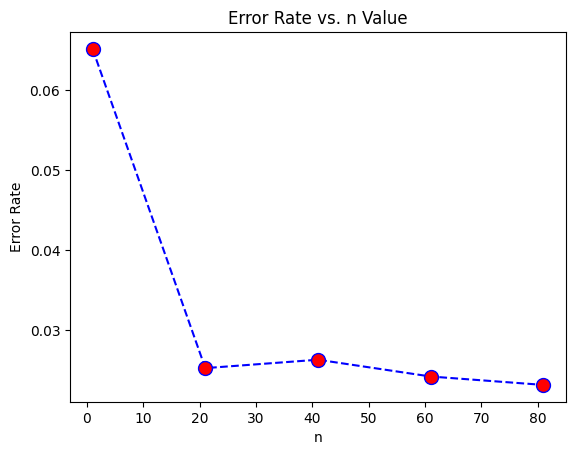

In [190]:
e=rf_error(100,x_train,y_train,x_test,y_test)

In [191]:
model=ensemble.RandomForestClassifier(n_estimators = e)
classify(model,x_train,y_train,x_test,y_test)

              precision    recall  f1-score   support

      female     0.9667    0.9852    0.9759       472
        male     0.9851    0.9666    0.9758       479

    accuracy                         0.9758       951
   macro avg     0.9759    0.9759    0.9758       951
weighted avg     0.9760    0.9758    0.9758       951



Lowest error is 0.028391167192429023 occurs at n=61.


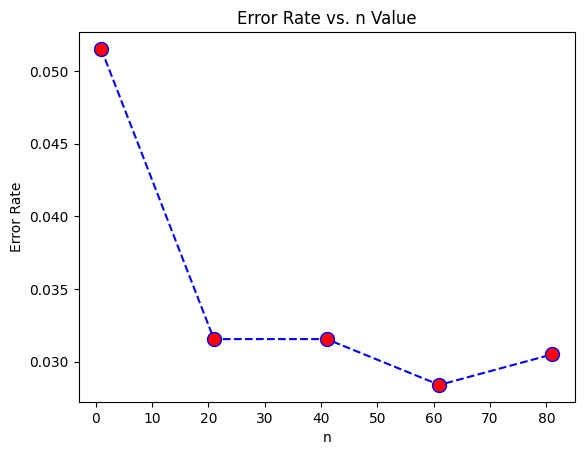

In [192]:
e=rf_error(100,x_train3,y_train3,x_test3,y_test3)

In [193]:
model=ensemble.RandomForestClassifier(n_estimators = e)
classify(model,x_train3,y_train3,x_test3,y_test3)

              precision    recall  f1-score   support

      female     0.9564    0.9767    0.9665       472
        male     0.9765    0.9562    0.9662       479

    accuracy                         0.9664       951
   macro avg     0.9665    0.9664    0.9664       951
weighted avg     0.9666    0.9664    0.9664       951



## Support Vector Machine
Using svm.SVC() để xây dựng Model

In [194]:
def svm_kernel(x_train,y_train,x_test,y_test):
    rate = []  # Danh sách lưu tỉ lệ chính xác
    kernel=['rbf','poly','linear'] # Danh sách các loại kernel
    for i in kernel:
        model = svm.SVC(kernel=i).fit(x_train, y_train)  # Khởi tạo và huấn luyện mô hình SVM với kernel là i
        y_pred = model.predict(x_train)  # Dự đoán nhãn của dữ liệu huấn luyện
        print(i, ' in-sample accuracy in SVM: ', accuracy_score(y_train,y_pred))
        y_pred = model.predict(x_test)  # Dự đoán nhãn của dữ liệu kiểm tra
        print(i, ' out-of-sample accuracy in SVM: ', accuracy_score(y_test,y_pred))
        rate.append(accuracy_score(y_test, y_pred))  # Thêm tỉ lệ chính xác vào danh sách
    nloc = rate.index(max(rate))  # Tìm vị trí của giá trị tỉ lệ chính xác cao nhất trong danh sách
    print("Highest accuracy is %s occurs at %s kernel." % (rate[nloc], kernel[nloc]))
    return kernel[nloc]  # Trả về kernel có độ chính xác cao nhất

In [158]:
def svm_error(k, C, x_train, y_train, x_test, y_test):
    error_rate = [] # Danh sách lưu tỉ lệ lỗi
    C = range(1,C) # Tạo danh sách các giá trị C từ 1 đến C-1
    for i in C:
        model = svm.SVC(kernel=k, C=i).fit(x_train, y_train)  # Khởi tạo và huấn luyện mô hình SVM với kernel là k và giá trị C là i
        y_pred = model.predict(x_test)  # Dự đoán nhãn của dữ liệu kiểm tra
        error_rate.append(np.mean(y_pred != y_test))  # Tính tỉ lệ lỗi và thêm vào danh sách
    cloc = error_rate.index(min(error_rate))  # Tìm vị trí của giá trị lỗi thấp nhất
    
    # Vẽ biểu đồ tỉ lệ lỗi so với giá trị C
    print("Lowest error is %s occurs at C=%s." % (error_rate[cloc], C[cloc]))

    plt.plot(C, error_rate, color='blue', linestyle='dashed', marker='o',
             markerfacecolor='red', markersize=10)
    plt.title('Error Rate vs. C Value')
    plt.xlabel('C')
    plt.ylabel('Error Rate')
    plt.show()
    return C[cloc]

In [159]:
k=svm_kernel(x_train,y_train,x_test,y_test)

rbf  in-sample accuracy in SVM:  0.9815065403698692
rbf  out-of-sample accuracy in SVM:  0.9726603575184016
poly  in-sample accuracy in SVM:  0.984212900315742
poly  out-of-sample accuracy in SVM:  0.9716088328075709
linear  in-sample accuracy in SVM:  0.9769959404600812
linear  out-of-sample accuracy in SVM:  0.9695057833859095
Highest accuracy is 0.9726603575184016 occurs at rbf kernel.


Lowest error is 0.025236593059936908 occurs at C=2.


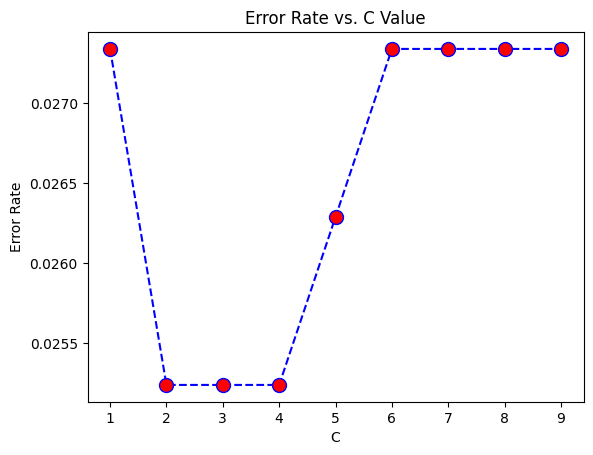

In [160]:
c=svm_error(k,10,x_train,y_train,x_test,y_test)

In [161]:
model=svm.SVC(kernel=k,C=c)
classify(model,x_train,y_train,x_test,y_test)

              precision    recall  f1-score   support

      female     0.9765    0.9724    0.9745       471
        male     0.9730    0.9771    0.9751       480

    accuracy                         0.9748       951
   macro avg     0.9748    0.9747    0.9748       951
weighted avg     0.9748    0.9748    0.9748       951



In [162]:
k=svm_kernel(x_train3,y_train3,x_test3,y_test3)

rbf  in-sample accuracy in SVM:  0.9742895805142084
rbf  out-of-sample accuracy in SVM:  0.9695057833859095
poly  in-sample accuracy in SVM:  0.9733874605322508
poly  out-of-sample accuracy in SVM:  0.9631966351209253
linear  in-sample accuracy in SVM:  0.9688768606224628
linear  out-of-sample accuracy in SVM:  0.961093585699264
Highest accuracy is 0.9695057833859095 occurs at rbf kernel.


Lowest error is 0.030494216614090432 occurs at C=1.


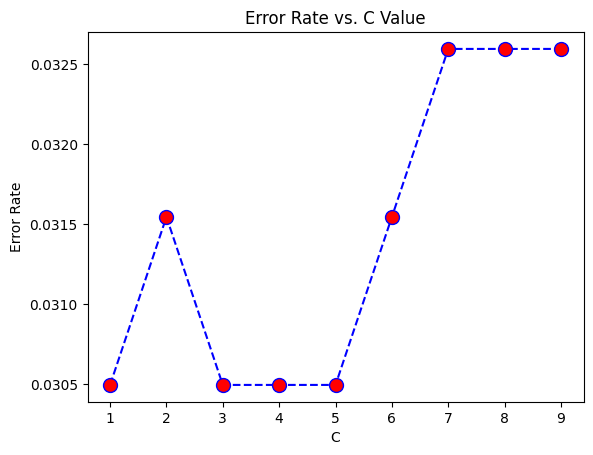

In [163]:
c=svm_error(k,10,x_train3,y_train3,x_test3,y_test3)

In [164]:
model=svm.SVC(kernel=k,C=c)
classify(model,x_train3,y_train3,x_test3,y_test3)

              precision    recall  f1-score   support

      female     0.9742    0.9639    0.9691       471
        male     0.9649    0.9750    0.9699       480

    accuracy                         0.9695       951
   macro avg     0.9696    0.9695    0.9695       951
weighted avg     0.9696    0.9695    0.9695       951

